In [27]:
import sys
sys.path.append("./HPO_B")  # Adjust the path to import from the parent directory
from hpob_handler import HPOBHandler
from methods.random_search import RandomSearch
import matplotlib.pyplot as plt
import pandas as pd

In [28]:
result_folder = "./results/"
benchmark_name = "HPO-B"
method_names = ["Random-Search", "GP", "PFNs4BO-HEBO", "ourPFNs" ] #"GP"]#, "PFNs4BO-HEBO", "ourPFNs"]
search_space_id = "4796"

hpob_hdlr = HPOBHandler(root_dir="./HPO_B/hpob-data/", mode="v3-test")
dataset_ids = hpob_hdlr.get_datasets(search_space_id)

df_list = []
for method_name in method_names:
    for dataset_id in dataset_ids:
        df = pd.read_csv(result_folder + benchmark_name + "_" + method_name + "_" + search_space_id +"_"+ dataset_id + ".csv")
        df_list.append(df)
df = pd.concat(df_list, ignore_index=True)

Loading HPO-B handler
Loading data...


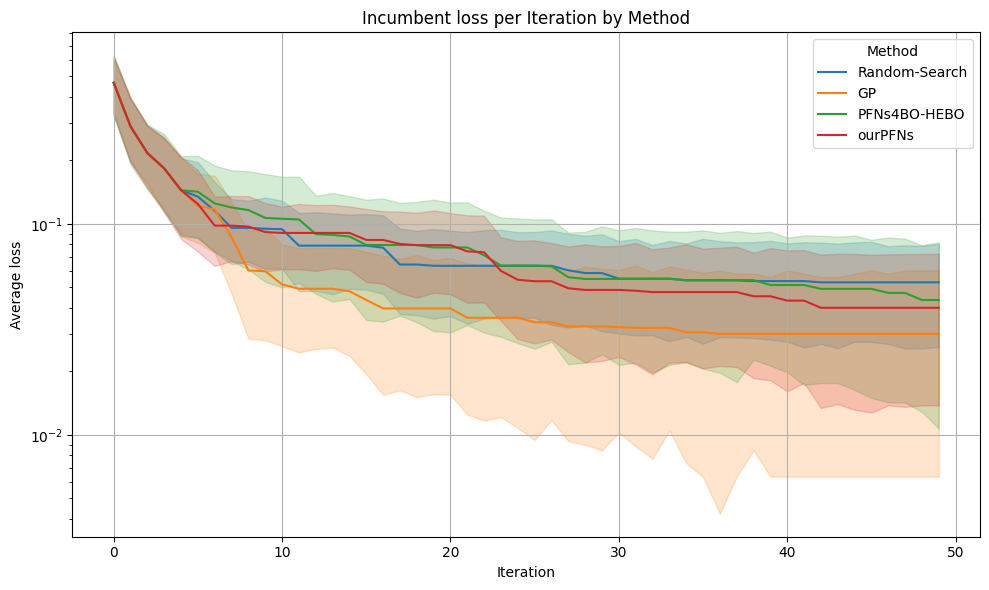

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

df['loss'] = 1 - df['performance']

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x='iteration',
    y='loss',
    hue='method',
    estimator='mean',
    errorbar=('ci', 95)
)
plt.title('Incumbent loss per Iteration by Method')
plt.xlabel('Iteration')
plt.ylabel('Average loss')
plt.yscale('log')
plt.legend(title='Method')
plt.grid(True)
plt.tight_layout()
plt.show()

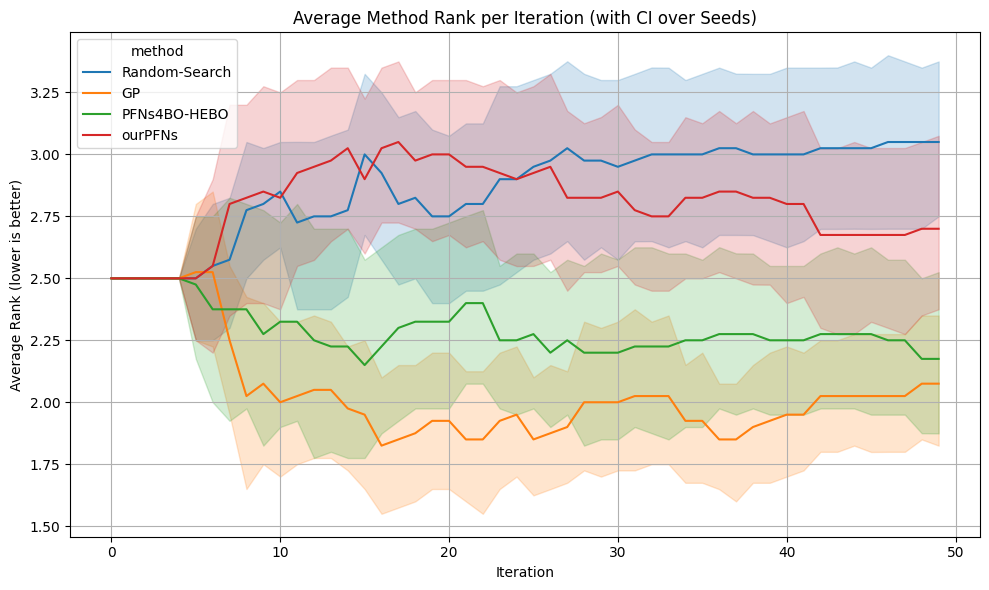

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Compute average incumbent_acc per method, iteration, and seed
agg = df
# Step 2: Compute rank per iteration and seed
agg['rank'] = agg.groupby(['search_space_id','dataset_id', 'iteration', 'seed'])['loss'].rank(ascending=True, method='average')
# Step 3: Plot with seaborn using confidence intervals or std
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=agg,
    x='iteration',
    y='rank',
    hue='method',
    estimator='mean',
    errorbar=('ci', 95)
)
plt.title('Average Method Rank per Iteration (with CI over Seeds)')
plt.xlabel('Iteration')
plt.ylabel('Average Rank (lower is better)')
plt.grid(True)
plt.tight_layout()
plt.show()
